# SEIRS-SEI Malaria Model — Initial Condition Calibration

Calibrating S_H0, E_H0, and I_M0 to match the initial disease trend.

**Fixed**: I_H0 (from case data), R_H0 ~ 10-15% of N (recovered humans, fixed at 12%), M_0 ~ 10×N, E_M0 ~ 3×I_M0

**To calibrate**: S_H0 (susceptible humans), E_H0 (exposed humans), I_M0 (infectious mosquitoes)

**Constraint**: S_H0 + E_H0 + I_H0 + R_H0 = N_2017 (R_H0 derived as residual, enforced to be ~10-15% of N)

In [3]:
import sys
sys.path.append("..")

from ode_models.seirs_sei_ode_shared import *
%matplotlib inline

Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos in 2012 was estimated to be ~4
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=80342, E_M=2511, I_M=837


In [4]:
#### Yearly Simulation (2017-2023)
years = 2017 #list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

start = f"{years}-01-01"
end = f"{years}-12-31"

USE_SMOOTH_CLIMATE = True

#### Simulation function with custom initial conditions
def run_simulation_with_IC(initial_state, M_prime_val=None):
    if M_prime_val is None:
        M_prime_val = M_prime
    state = initial_state.copy()
    all_IH = []
    all_dates = []
    N = round(pop_by_year[years])

    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
            year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                                T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                                c1, c2, D1, b1, b2, A, B, C, DD,
                                Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                                optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                                gamma, R_L, M_prime_val, tau_H, omega,
                                M_min=M_min, permanent_factor=permanent_factor, use_smooth_climate=USE_SMOOTH_CLIMATE)
    sol = solve_ivp(ode_func, [0, num_days], state,
                        t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')
    if not sol.success:
        return np.array([]), np.array([])
    state = sol.y[:, -1].copy()
    state = np.maximum(state, 0)
    t_interp = np.linspace(0, sol.t[-1], len(year_climate))
    IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
    all_IH.extend(IH_interp)
    all_dates.extend(year_climate['date'].values)
    
    return np.array(all_dates), np.array(all_IH)

In [5]:
rural_cases_df = rural_cases_df[(rural_cases_df['date'] >= start) & (rural_cases_df['date'] <= end)].reset_index(drop=True)
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

In [6]:
#### Baseline: current initial conditions
dates_base, IH_base = run_simulation_with_IC(initial_state_2017)
baseline_mse = np.mean((IH_base - rural_cases_df['active_total'].values) ** 2)
print(f"Baseline MSE (current ICs): {baseline_mse:,.2f}")
print(f"  S_H0={S_H0}, E_H0={E_H0}, I_H0={I_H0}, R_H0={R_H0}")
print(f"  S_M0={S_M0}, E_M0={E_M0}, I_M0={I_M0}")

Baseline MSE (current ICs): 969,094.00
  S_H0=5752, E_H0=418, I_H0=944, R_H0=1255
  S_M0=80342, E_M0=2511, I_M0=837


In [7]:
#### Objective function for IC calibration
# Params: [S_H0_frac, E_H0_frac, I_M0_ratio]
# S_H0_frac = S_H0 / N_2017
# E_H0_frac = E_H0 / N_2017
# I_M0_ratio = I_M0 / M_0
# R_H0 = N_2017 - S_H0 - E_H0 - I_H0 (residual, enforced 1-85% of N)

def objective_IC(params):
    S_H0_frac, E_H0_frac, I_M0_ratio = params
    
    S_H0 = round(S_H0_frac * N_2017)
    E_H0 = round(E_H0_frac * N_2017)
    I_M0 = round(I_M0_ratio * M_0)
    
    if I_M0 > M_0 / 4:
        return 1e15
    
    R_H0 = N_2017 - S_H0 - E_H0 - I_H0
    if R_H0 < 0 or R_H0 > N_2017:
        return 1e15
    R_frac = R_H0 / N_2017
    if not (0.01 <= R_frac <= 0.85):
        return 1e15
    
    E_M0 = round(3 * I_M0)
    S_M0 = M_0 - E_M0 - I_M0
    if S_M0 < 0:
        return 1e15
    
    init_state = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])
    dates, IH = run_simulation_with_IC(init_state)
    
    if len(dates) == 0:
        return 1e15
    
    model_interp = interp1d(pd.to_datetime(dates).astype(np.int64), IH, kind='linear', fill_value='extrapolate')
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values
    mse = np.mean((model_at_obs - observed) ** 2)
    return mse


In [8]:
#### Grid search over initial condition parameters
# Ranges:
#   S_H0_frac:  0.05 to 0.25  (5% to 25% of N)
#   E_H0_frac:  0.15 to 0.60  (15% to 60% of N)
#   I_M0_ratio: 0.001 to 0.05 (0.1% to 5% of M_0)
#   R_H0 = N_2017 - S_H0 - E_H0 - I_H0 (residual, enforced 1-85%)

S_H0_candidates = [0.05, 0.10, 0.20, 0.25]
E_H0_candidates = [0.15, 0.25, 0.30, 0.45, 0.50, 0.60]
I_M0_candidates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

print("Grid search for initial conditions...")
print(f"Grid size: {len(S_H0_candidates)} x {len(E_H0_candidates)} x {len(I_M0_candidates)} = {len(S_H0_candidates)*len(E_H0_candidates)*len(I_M0_candidates)}")

best_params = None
best_mse = 1e15
results = []

for sh in S_H0_candidates:
    for eh in E_H0_candidates:
        for im in I_M0_candidates:
            rh_frac = 1.0 - sh - eh - I_H0/N_2017
            if not (0.01 <= rh_frac <= 0.85):
                continue
            mse = objective_IC([sh, eh, im])
            results.append((sh, eh, im, mse))
            if mse < best_mse:
                best_mse = mse
                best_params = (sh, eh, im)
            print(f"  S_H0={sh:.2f}, E_H0={eh:.2f}, I_M0={im:.3f} -> MSE={mse:>12,.2f}")

print(f"\nBest from grid:")
print(f"  S_H0_frac = {best_params[0]:.2f}  ({round(best_params[0]*N_2017)} people)")
print(f"  E_H0_frac = {best_params[1]:.2f}  ({round(best_params[1]*N_2017)} people)")
print(f"  I_M0_ratio = {best_params[2]:.3f} ({round(best_params[2]*M_0)} mosquitos)")
rh_result = 1.0 - best_params[0] - best_params[1] - I_H0/N_2017
print(f"  R_H0_frac (residual) = {rh_result:.3f}  ({round(rh_result*N_2017)} people)")
print(f"  MSE = {best_mse:,.2f}")


Grid search for initial conditions...
Grid size: 4 x 6 x 6 = 144
  S_H0=0.05, E_H0=0.15, I_M0=0.001 -> MSE=1,094,010.34
  S_H0=0.05, E_H0=0.15, I_M0=0.002 -> MSE=1,094,387.48
  S_H0=0.05, E_H0=0.15, I_M0=0.005 -> MSE=1,094,582.01
  S_H0=0.05, E_H0=0.15, I_M0=0.010 -> MSE=1,095,529.59
  S_H0=0.05, E_H0=0.15, I_M0=0.020 -> MSE=1,096,949.02
  S_H0=0.05, E_H0=0.15, I_M0=0.050 -> MSE=1,102,952.29
  S_H0=0.05, E_H0=0.25, I_M0=0.001 -> MSE=1,272,770.13
  S_H0=0.05, E_H0=0.25, I_M0=0.002 -> MSE=1,273,749.55
  S_H0=0.05, E_H0=0.25, I_M0=0.005 -> MSE=1,276,201.67
  S_H0=0.05, E_H0=0.25, I_M0=0.010 -> MSE=1,280,476.75
  S_H0=0.05, E_H0=0.25, I_M0=0.020 -> MSE=1,289,171.89
  S_H0=0.05, E_H0=0.25, I_M0=0.050 -> MSE=1,313,554.40
  S_H0=0.05, E_H0=0.30, I_M0=0.001 -> MSE=1,448,797.33
  S_H0=0.05, E_H0=0.30, I_M0=0.002 -> MSE=1,449,874.27
  S_H0=0.05, E_H0=0.30, I_M0=0.005 -> MSE=1,453,670.38
  S_H0=0.05, E_H0=0.30, I_M0=0.010 -> MSE=1,459,199.40
  S_H0=0.05, E_H0=0.30, I_M0=0.020 -> MSE=1,470,597.15


In [9]:
#### Fine optimization with L-BFGS-B
from scipy.optimize import minimize

print("Fine optimization with L-BFGS-B...")

initial_guess = [best_params[0], best_params[1], best_params[2]]
bounds = [(0.01, 0.30), (0.10, 0.65), (0.0005, 0.06)]  # [S_H0_frac, E_H0_frac, I_M0_ratio]

result = minimize(
    objective_IC,
    initial_guess,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 50, 'ftol': 1e-6}
)

opt_sh, opt_eh, opt_im = result.x
opt_S_H0 = round(opt_sh * N_2017)
opt_E_H0 = round(opt_eh * N_2017)
opt_I_M0 = round(opt_im * M_0)
opt_E_M0 = round(3 * opt_I_M0)
opt_R_H0 = N_2017 - opt_S_H0 - opt_E_H0 - I_H0
opt_S_M0 = M_0 - opt_E_M0 - opt_I_M0

print(f"Optimized ICs (MSE = {result.fun:,.2f}):")
print(f"  S_H0 = {opt_S_H0}, E_H0 = {opt_E_H0}, I_H0 = {I_H0}, R_H0 = {opt_R_H0}")
print(f"  S_M0 = {opt_S_M0}, E_M0 = {opt_E_M0}, I_M0 = {opt_I_M0}")
print(f"  (S_H0_frac={opt_sh:.3f}, E_H0_frac={opt_eh:.3f}, I_M0_ratio={opt_im:.4f})")
rh_frac = opt_R_H0 / N_2017
print(f"  R_H0_frac (residual) = {rh_frac:.3f}")


Fine optimization with L-BFGS-B...
Optimized ICs (MSE = 1,058,145.79):
  S_H0 = 2092, E_H0 = 1255, I_H0 = 944, R_H0 = 4078
  S_M0 = 83354, E_M0 = 252, I_M0 = 84
  (S_H0_frac=0.250, E_H0_frac=0.150, I_M0_ratio=0.0010)
  R_H0_frac (residual) = 0.487


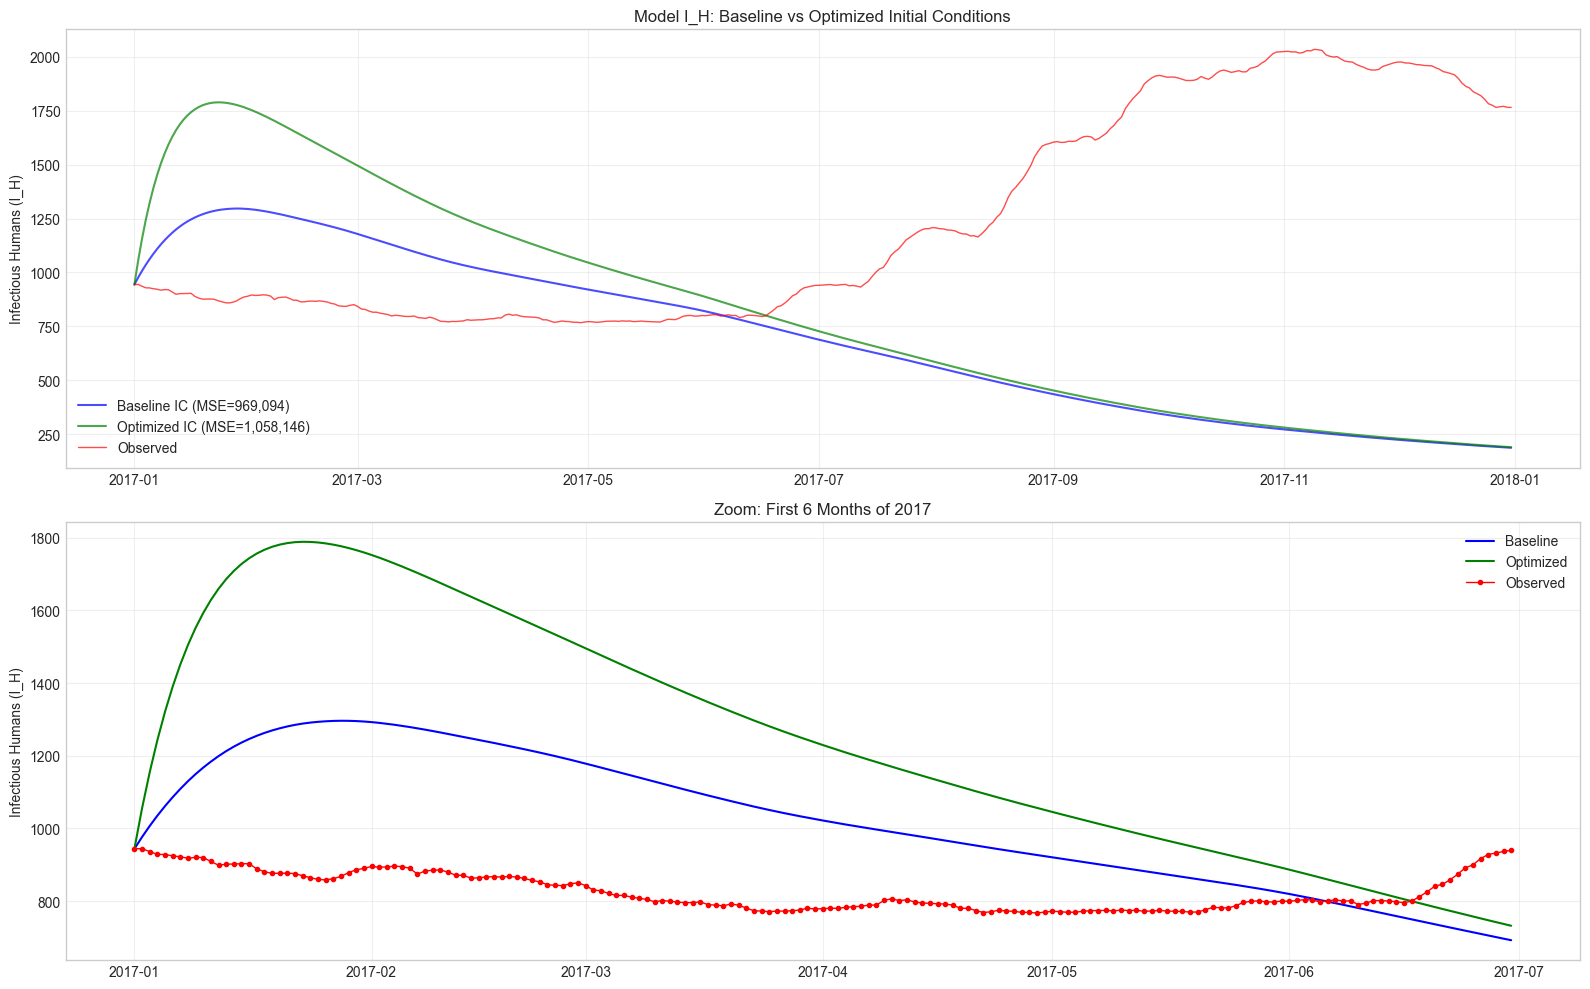

In [10]:
#### Compare baseline vs optimized ICs
opt_init_state = np.array([opt_S_H0, opt_E_H0, I_H0, opt_R_H0, opt_S_M0, opt_E_M0, opt_I_M0])
dates_opt, IH_opt = run_simulation_with_IC(opt_init_state)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_base), IH_base, 'b-', linewidth=1.5, alpha=0.7, label=f'Baseline IC (MSE={baseline_mse:,.0f})')
ax1.plot(pd.to_datetime(dates_opt), IH_opt, 'g-', linewidth=1.5, alpha=0.7, label=f'Optimized IC (MSE={result.fun:,.0f})')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)')
ax1.set_title('Model I_H: Baseline vs Optimized Initial Conditions')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
# Zoom to first 180 days
mask_base = pd.to_datetime(dates_base) < pd.to_datetime('2017-07-01')
mask_opt = pd.to_datetime(dates_opt) < pd.to_datetime('2017-07-01')
mask_obs = rural_cases_df['date'] < pd.to_datetime('2017-07-01')
ax2.plot(pd.to_datetime(dates_base)[mask_base], IH_base[mask_base], 'b-', linewidth=1.5, label='Baseline')
ax2.plot(pd.to_datetime(dates_opt)[mask_opt], IH_opt[mask_opt], 'g-', linewidth=1.5, label='Optimized')
ax2.plot(rural_cases_df['date'][mask_obs], rural_cases_df['active_total'][mask_obs], 'ro-', markersize=3, linewidth=1.0, label='Observed')
ax2.set_ylabel('Infectious Humans (I_H)')
ax2.set_title('Zoom: First 6 Months of 2017')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Best results from grid search 1 (fitting S_H0, E_H0, I_M0):

$S_{H0}/N = 0.75$  (6277 people)

$E_{H0}/N = 0.05$  (418 people)

$I_{M0}/M = 0.020$ (1674 mosquitos)

$R_{H0}/N$ (residual) $\approx 0.09$ (754 people)

MSE = 937,019.00

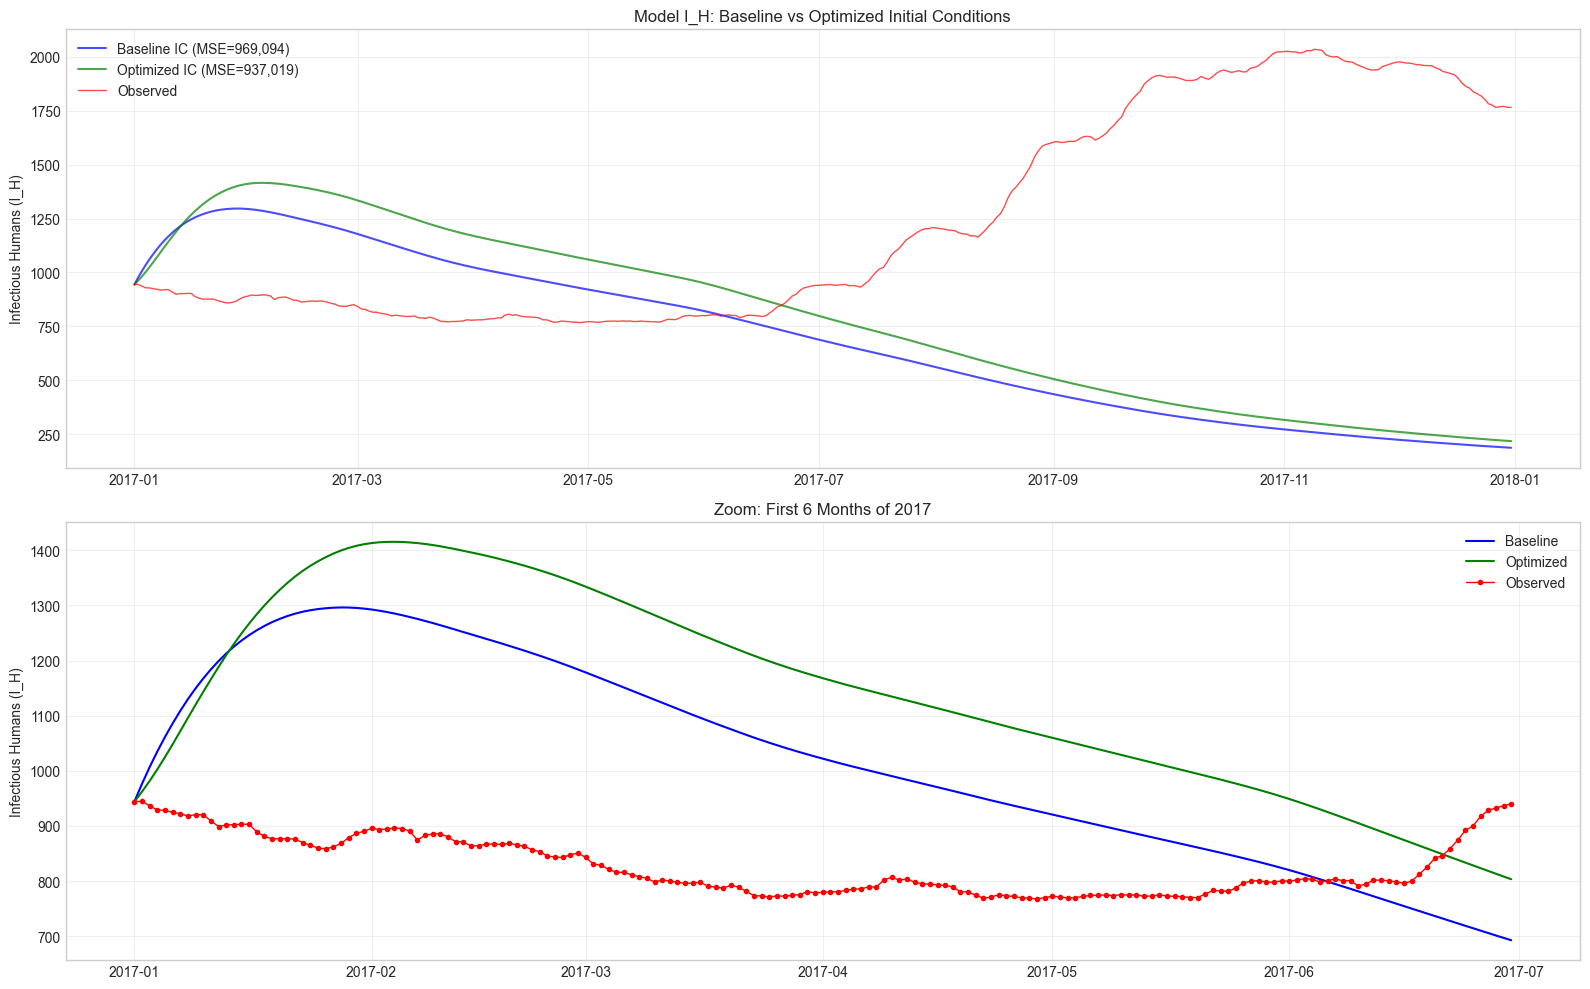

In order to try and make $I_H$ decrease, $E_{H0}$ would need to have a lower value. In order to reach this, we will replicate the fitting, using smaller possible fractions of N as possible values for $E_{H0}$:

In [13]:
#### Grid search over initial condition parameters (refined S_H0/E_H0 range)
# Ranges:


#   S_H0_frac:  0.01 to 0.20  (1% to 20% of N)
#   E_H0_frac:  0.10 to 0.60  (10% to 70% of N)
#   I_M0_ratio: 0.001 to 0.05 (0.1% to 5% of M_0)
#   R_H0 = N_2017 - S_H0 - E_H0 - I_H0 (residual, enforced 1-85%)

S_H0_candidates = [0.01, 0.05, 0.10, 0.20]
E_H0_candidates = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]
I_M0_candidates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

print("Grid search for initial conditions...")
print(f"Grid size: {len(S_H0_candidates)} x {len(E_H0_candidates)} x {len(I_M0_candidates)} = {len(S_H0_candidates)*len(E_H0_candidates)*len(I_M0_candidates)}")

best_params = None
best_mse = 1e15
results = []

for sh in S_H0_candidates:
    for eh in E_H0_candidates:
        for im in I_M0_candidates:
            rh_frac = 1.0 - sh - eh - I_H0/N_2017
            if not (0.01 <= rh_frac <= 0.85):
                continue
            mse = objective_IC([sh, eh, im])
            results.append((sh, eh, im, mse))
            if mse < best_mse:
                best_mse = mse
                best_params = (sh, eh, im)
            print(f"  S_H0={sh:.2f}, E_H0={eh:.2f}, I_M0={im:.3f} -> MSE={mse:>12,.2f}")

print(f"\nBest from grid:")
print(f"  S_H0_frac = {best_params[0]:.2f}  ({round(best_params[0]*N_2017)} people)")
print(f"  E_H0_frac = {best_params[1]:.2f}  ({round(best_params[1]*N_2017)} people)")
print(f"  I_M0_ratio = {best_params[2]:.3f} ({round(best_params[2]*M_0)} mosquitos)")
rh_result = 1.0 - best_params[0] - best_params[1] - I_H0/N_2017
print(f"  R_H0_frac (residual) = {rh_result:.3f}  ({round(rh_result*N_2017)} people)")
print(f"  MSE = {best_mse:,.2f}")


Grid search for initial conditions...
Grid size: 4 x 7 x 6 = 168
  S_H0=0.01, E_H0=0.10, I_M0=0.001 -> MSE=1,101,683.22
  S_H0=0.01, E_H0=0.10, I_M0=0.002 -> MSE=1,101,686.42
  S_H0=0.01, E_H0=0.10, I_M0=0.005 -> MSE=1,101,222.12
  S_H0=0.01, E_H0=0.10, I_M0=0.010 -> MSE=1,100,427.77
  S_H0=0.01, E_H0=0.10, I_M0=0.020 -> MSE=1,098,782.21
  S_H0=0.01, E_H0=0.10, I_M0=0.050 -> MSE=1,095,082.47
  S_H0=0.01, E_H0=0.20, I_M0=0.001 -> MSE=1,159,589.53
  S_H0=0.01, E_H0=0.20, I_M0=0.002 -> MSE=1,159,985.15
  S_H0=0.01, E_H0=0.20, I_M0=0.005 -> MSE=1,160,412.55
  S_H0=0.01, E_H0=0.20, I_M0=0.010 -> MSE=1,161,745.06
  S_H0=0.01, E_H0=0.20, I_M0=0.020 -> MSE=1,163,860.76
  S_H0=0.01, E_H0=0.20, I_M0=0.050 -> MSE=1,170,363.82
  S_H0=0.01, E_H0=0.30, I_M0=0.001 -> MSE=1,447,202.49
  S_H0=0.01, E_H0=0.30, I_M0=0.002 -> MSE=1,447,655.16
  S_H0=0.01, E_H0=0.30, I_M0=0.005 -> MSE=1,449,030.89
  S_H0=0.01, E_H0=0.30, I_M0=0.010 -> MSE=1,451,615.36
  S_H0=0.01, E_H0=0.30, I_M0=0.020 -> MSE=1,456,441.15


In [14]:
#### Fine optimization with L-BFGS-B

print("Fine optimization with L-BFGS-B...")

initial_guess = [best_params[0], best_params[1], best_params[2]]
bounds = [(0.005, 0.25), (0.05, 0.75), (0.0005, 0.06)]  # [S_H0_frac, E_H0_frac, I_M0_ratio]

result = minimize(
    objective_IC,
    initial_guess,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 50, 'ftol': 1e-6}
)

opt_sh, opt_eh, opt_im = result.x
opt_S_H0 = round(opt_sh * N_2017)
opt_E_H0 = round(opt_eh * N_2017)
opt_I_M0 = round(opt_im * M_0)
opt_E_M0 = round(3 * opt_I_M0)
opt_R_H0 = N_2017 - opt_S_H0 - opt_E_H0 - I_H0
opt_S_M0 = M_0 - opt_E_M0 - opt_I_M0

print(f"Optimized ICs (MSE = {result.fun:,.2f}):")
print(f"  S_H0 = {opt_S_H0}, E_H0 = {opt_E_H0}, I_H0 = {I_H0}, R_H0 = {opt_R_H0}")
print(f"  S_M0 = {opt_S_M0}, E_M0 = {opt_E_M0}, I_M0 = {opt_I_M0}")
print(f"  (S_H0_frac={opt_sh:.3f}, E_H0_frac={opt_eh:.3f}, I_M0_ratio={opt_im:.4f})")
rh_frac = opt_R_H0 / N_2017
print(f"  R_H0_frac (residual) = {rh_frac:.3f}")


Fine optimization with L-BFGS-B...
Optimized ICs (MSE = 1,053,496.30):
  S_H0 = 1674, E_H0 = 837, I_H0 = 944, R_H0 = 4914
  S_M0 = 76994, E_M0 = 5022, I_M0 = 1674
  (S_H0_frac=0.200, E_H0_frac=0.100, I_M0_ratio=0.0200)
  R_H0_frac (residual) = 0.587


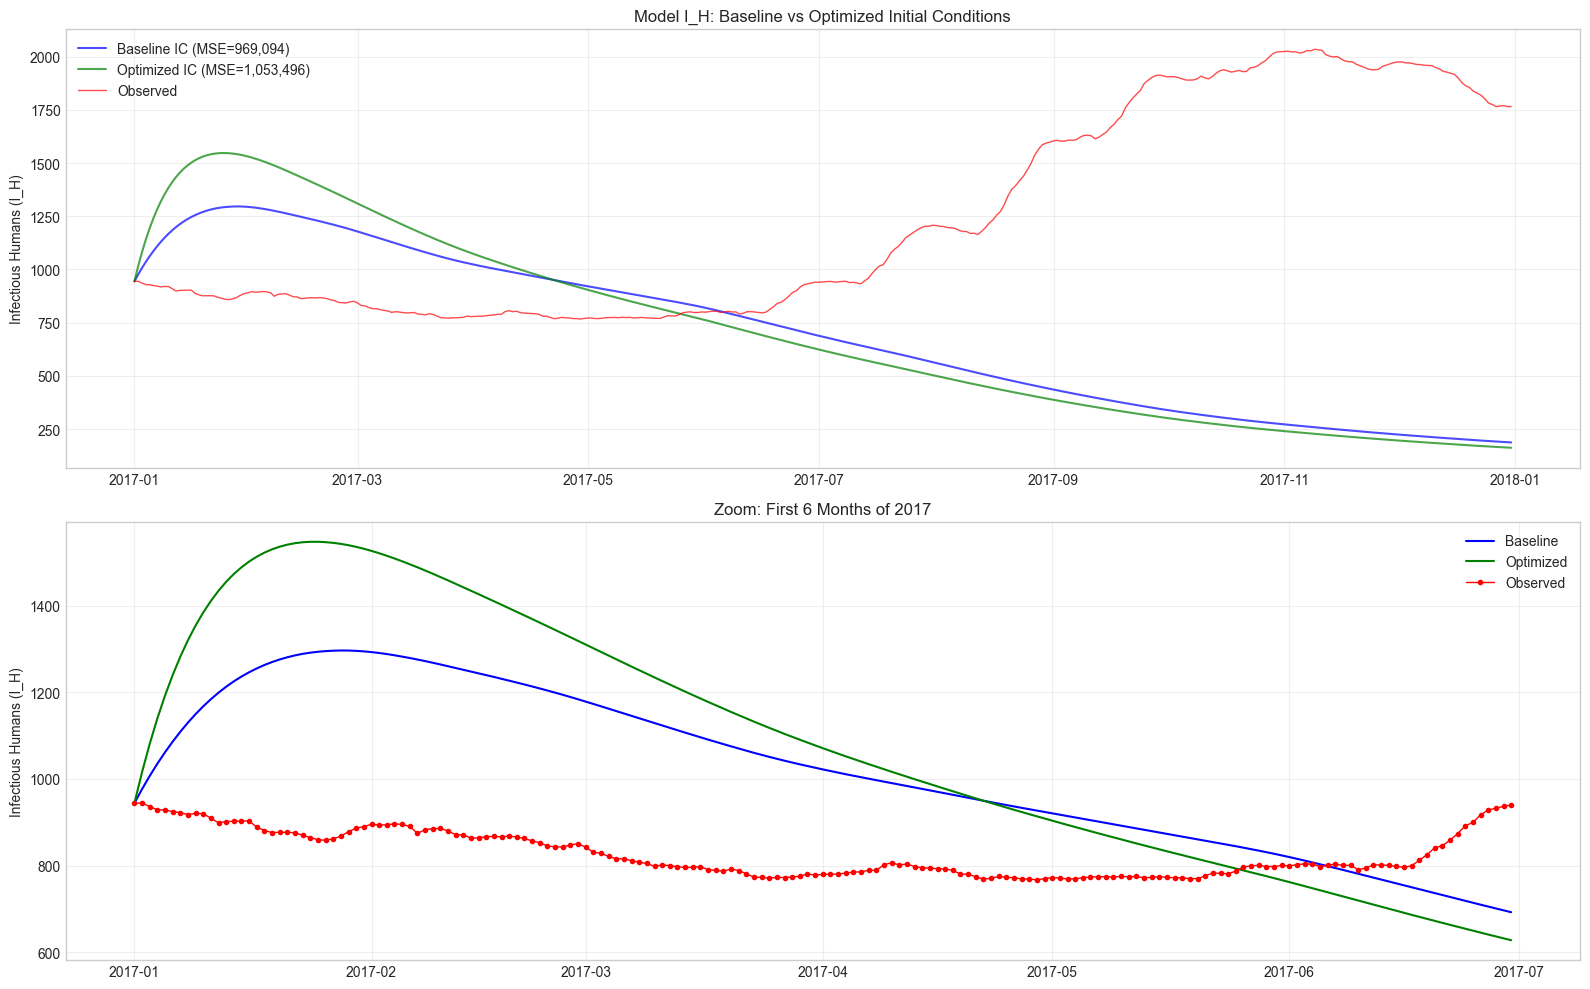

In [15]:
#### Compare baseline vs optimized ICs
opt_init_state = np.array([opt_S_H0, opt_E_H0, I_H0, opt_R_H0, opt_S_M0, opt_E_M0, opt_I_M0])
dates_opt, IH_opt = run_simulation_with_IC(opt_init_state)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_base), IH_base, 'b-', linewidth=1.5, alpha=0.7, label=f'Baseline IC (MSE={baseline_mse:,.0f})')
ax1.plot(pd.to_datetime(dates_opt), IH_opt, 'g-', linewidth=1.5, alpha=0.7, label=f'Optimized IC (MSE={result.fun:,.0f})')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)')
ax1.set_title('Model I_H: Baseline vs Optimized Initial Conditions')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
# Zoom to first 180 days
mask_base = pd.to_datetime(dates_base) < pd.to_datetime('2017-07-01')
mask_opt = pd.to_datetime(dates_opt) < pd.to_datetime('2017-07-01')
mask_obs = rural_cases_df['date'] < pd.to_datetime('2017-07-01')
ax2.plot(pd.to_datetime(dates_base)[mask_base], IH_base[mask_base], 'b-', linewidth=1.5, label='Baseline')
ax2.plot(pd.to_datetime(dates_opt)[mask_opt], IH_opt[mask_opt], 'g-', linewidth=1.5, label='Optimized')
ax2.plot(rural_cases_df['date'][mask_obs], rural_cases_df['active_total'][mask_obs], 'ro-', markersize=3, linewidth=1.0, label='Observed')
ax2.set_ylabel('Infectious Humans (I_H)')
ax2.set_title('Zoom: First 6 Months of 2017')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## First-Difference Fitting

Instead of matching absolute I_H values, we match the **day-over-day change** in I_H.
This forces the model to get the **trend** right — the initial decrease is penalized
as heavily as any other day's mismatch.

Metric: MSE of ΔI_H = `(model_diff - obs_diff)^2` averaged over all days.

In [17]:
#### First-difference objective: match day-over-day changes in I_H
# Params: [S_H0_frac, E_H0_frac, I_M0_ratio]
# R_H0 = N_2017 - S_H0 - E_H0 - I_H0 (residual, enforced 1-85% of N)

def objective_IC_first_diff(params):
    S_H0_frac, E_H0_frac, I_M0_ratio = params

    S_H0 = round(S_H0_frac * N_2017)
    E_H0 = round(E_H0_frac * N_2017)
    I_M0 = round(I_M0_ratio * M_0)

    if I_M0 > M_0 / 4:
        return 1e15

    R_H0 = N_2017 - S_H0 - E_H0 - I_H0
    if R_H0 < 0 or R_H0 > N_2017:
        return 1e15
    R_frac = R_H0 / N_2017
    if not (0.01 <= R_frac <= 0.85):
        return 1e15

    E_M0 = round(3 * I_M0)
    S_M0 = M_0 - E_M0 - I_M0
    if S_M0 < 0:
        return 1e15

    init_state = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])
    dates, IH = run_simulation_with_IC(init_state)

    if len(dates) == 0:
        return 1e15

    model_interp = interp1d(
        pd.to_datetime(dates).astype(np.int64), IH,
        kind='linear', fill_value='extrapolate'
    )
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values

    model_diff = np.diff(model_at_obs)
    obs_diff = np.diff(observed)

    mse = np.mean((model_diff - obs_diff) ** 2)
    return mse


In [18]:
#### Grid search with first-difference metric
# Params: [S_H0_frac, E_H0_frac, I_M0_ratio]
# R_H0 = N_2017 - S_H0 - E_H0 - I_H0 (residual, enforced 1-85%)

# S_H0_candidates = [0.05, 0.10, 0.20, 0.25, 0.30, 0.40, 0.45]
# E_H0_candidates = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
# I_M0_candidates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

S_H0_candidates = [0.01, 0.05, 0.10, 0.20, 0.25]
E_H0_candidates = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
I_M0_candidates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]

print("Grid search (first-difference) for initial conditions...")
print(f"Grid size: {len(S_H0_candidates)} x {len(E_H0_candidates)} x {len(I_M0_candidates)} = {len(S_H0_candidates)*len(E_H0_candidates)*len(I_M0_candidates)}")

best_params_fd = None
best_score_fd = 1e15
results_fd = []

for sh in S_H0_candidates:
    for eh in E_H0_candidates:
        for im in I_M0_candidates:
            rh_frac = 1.0 - sh - eh - I_H0/N_2017
            if not (0.01 <= rh_frac <= 0.85):
                continue
            score = objective_IC_first_diff([sh, eh, im])
            results_fd.append((sh, eh, im, score))
            if score < best_score_fd:
                best_score_fd = score
                best_params_fd = (sh, eh, im)
            print(f"  S_H0={sh:.2f}, E_H0={eh:.2f}, I_M0={im:.3f} -> first-diff MSE={score:>12,.2f}")

print(f"\nBest from grid (first-difference):")
print(f"  S_H0_frac = {best_params_fd[0]:.2f}  ({round(best_params_fd[0]*N_2017)} people)")
print(f"  E_H0_frac = {best_params_fd[1]:.2f}  ({round(best_params_fd[1]*N_2017)} people)")
print(f"  I_M0_ratio = {best_params_fd[2]:.3f} ({round(best_params_fd[2]*M_0)} mosquitos)")
rh_result = 1.0 - best_params_fd[0] - best_params_fd[1] - I_H0/N_2017
print(f"  R_H0_frac (residual) = {rh_result:.3f}  ({round(rh_result*N_2017)} people)")
print(f"  First-diff MSE = {best_score_fd:,.2f}")


Grid search (first-difference) for initial conditions...
Grid size: 5 x 6 x 6 = 180
  S_H0=0.01, E_H0=0.10, I_M0=0.001 -> first-diff MSE=      200.88
  S_H0=0.01, E_H0=0.10, I_M0=0.002 -> first-diff MSE=      200.96
  S_H0=0.01, E_H0=0.10, I_M0=0.005 -> first-diff MSE=      201.21
  S_H0=0.01, E_H0=0.10, I_M0=0.010 -> first-diff MSE=      201.61
  S_H0=0.01, E_H0=0.10, I_M0=0.020 -> first-diff MSE=      202.44
  S_H0=0.01, E_H0=0.10, I_M0=0.050 -> first-diff MSE=      204.83
  S_H0=0.01, E_H0=0.20, I_M0=0.001 -> first-diff MSE=      466.70
  S_H0=0.01, E_H0=0.20, I_M0=0.002 -> first-diff MSE=      466.73
  S_H0=0.01, E_H0=0.20, I_M0=0.005 -> first-diff MSE=      467.29
  S_H0=0.01, E_H0=0.20, I_M0=0.010 -> first-diff MSE=      467.94
  S_H0=0.01, E_H0=0.20, I_M0=0.020 -> first-diff MSE=      469.56
  S_H0=0.01, E_H0=0.20, I_M0=0.050 -> first-diff MSE=      473.81
  S_H0=0.01, E_H0=0.30, I_M0=0.001 -> first-diff MSE=      909.41
  S_H0=0.01, E_H0=0.30, I_M0=0.002 -> first-diff MSE=     

In [19]:
#### Fine optimization with L-BFGS-B (first-difference)

print("Fine optimization with L-BFGS-B (first-difference)...")

initial_guess = [best_params_fd[0], best_params_fd[1], best_params_fd[2]]
bounds = [(0.005, 0.30), (0.05, 0.70), (0.0005, 0.06)]  # [S_H0_frac, E_H0_frac, I_M0_ratio]

result_fd = minimize(
    objective_IC_first_diff,
    initial_guess,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100, 'ftol': 1e-8}
)

opt_sh_fd, opt_eh_fd, opt_im_fd = result_fd.x
opt_S_H0_fd = round(opt_sh_fd * N_2017)
opt_E_H0_fd = round(opt_eh_fd * N_2017)
opt_I_M0_fd = round(opt_im_fd * M_0)
opt_E_M0_fd = round(3 * opt_I_M0_fd)
opt_R_H0_fd = N_2017 - opt_S_H0_fd - opt_E_H0_fd - I_H0
opt_S_M0_fd = M_0 - opt_E_M0_fd - opt_I_M0_fd

print(f"Optimized ICs (first-diff MSE = {result_fd.fun:,.2f}):")
print(f"  S_H0 = {opt_S_H0_fd}, E_H0 = {opt_E_H0_fd}, I_H0 = {I_H0}, R_H0 = {opt_R_H0_fd}")
print(f"  S_M0 = {opt_S_M0_fd}, E_M0 = {opt_E_M0_fd}, I_M0 = {opt_I_M0_fd}")
print(f"  (S_H0_frac={opt_sh_fd:.3f}, E_H0_frac={opt_eh_fd:.3f}, I_M0_ratio={opt_im_fd:.4f})")
rh_frac_fd = opt_R_H0_fd / N_2017
print(f"  R_H0_frac (residual) = {rh_frac_fd:.3f}")


Fine optimization with L-BFGS-B (first-difference)...
Optimized ICs (first-diff MSE = 200.88):
  S_H0 = 84, E_H0 = 837, I_H0 = 944, R_H0 = 6504
  S_M0 = 83354, E_M0 = 252, I_M0 = 84
  (S_H0_frac=0.010, E_H0_frac=0.100, I_M0_ratio=0.0010)
  R_H0_frac (residual) = 0.777


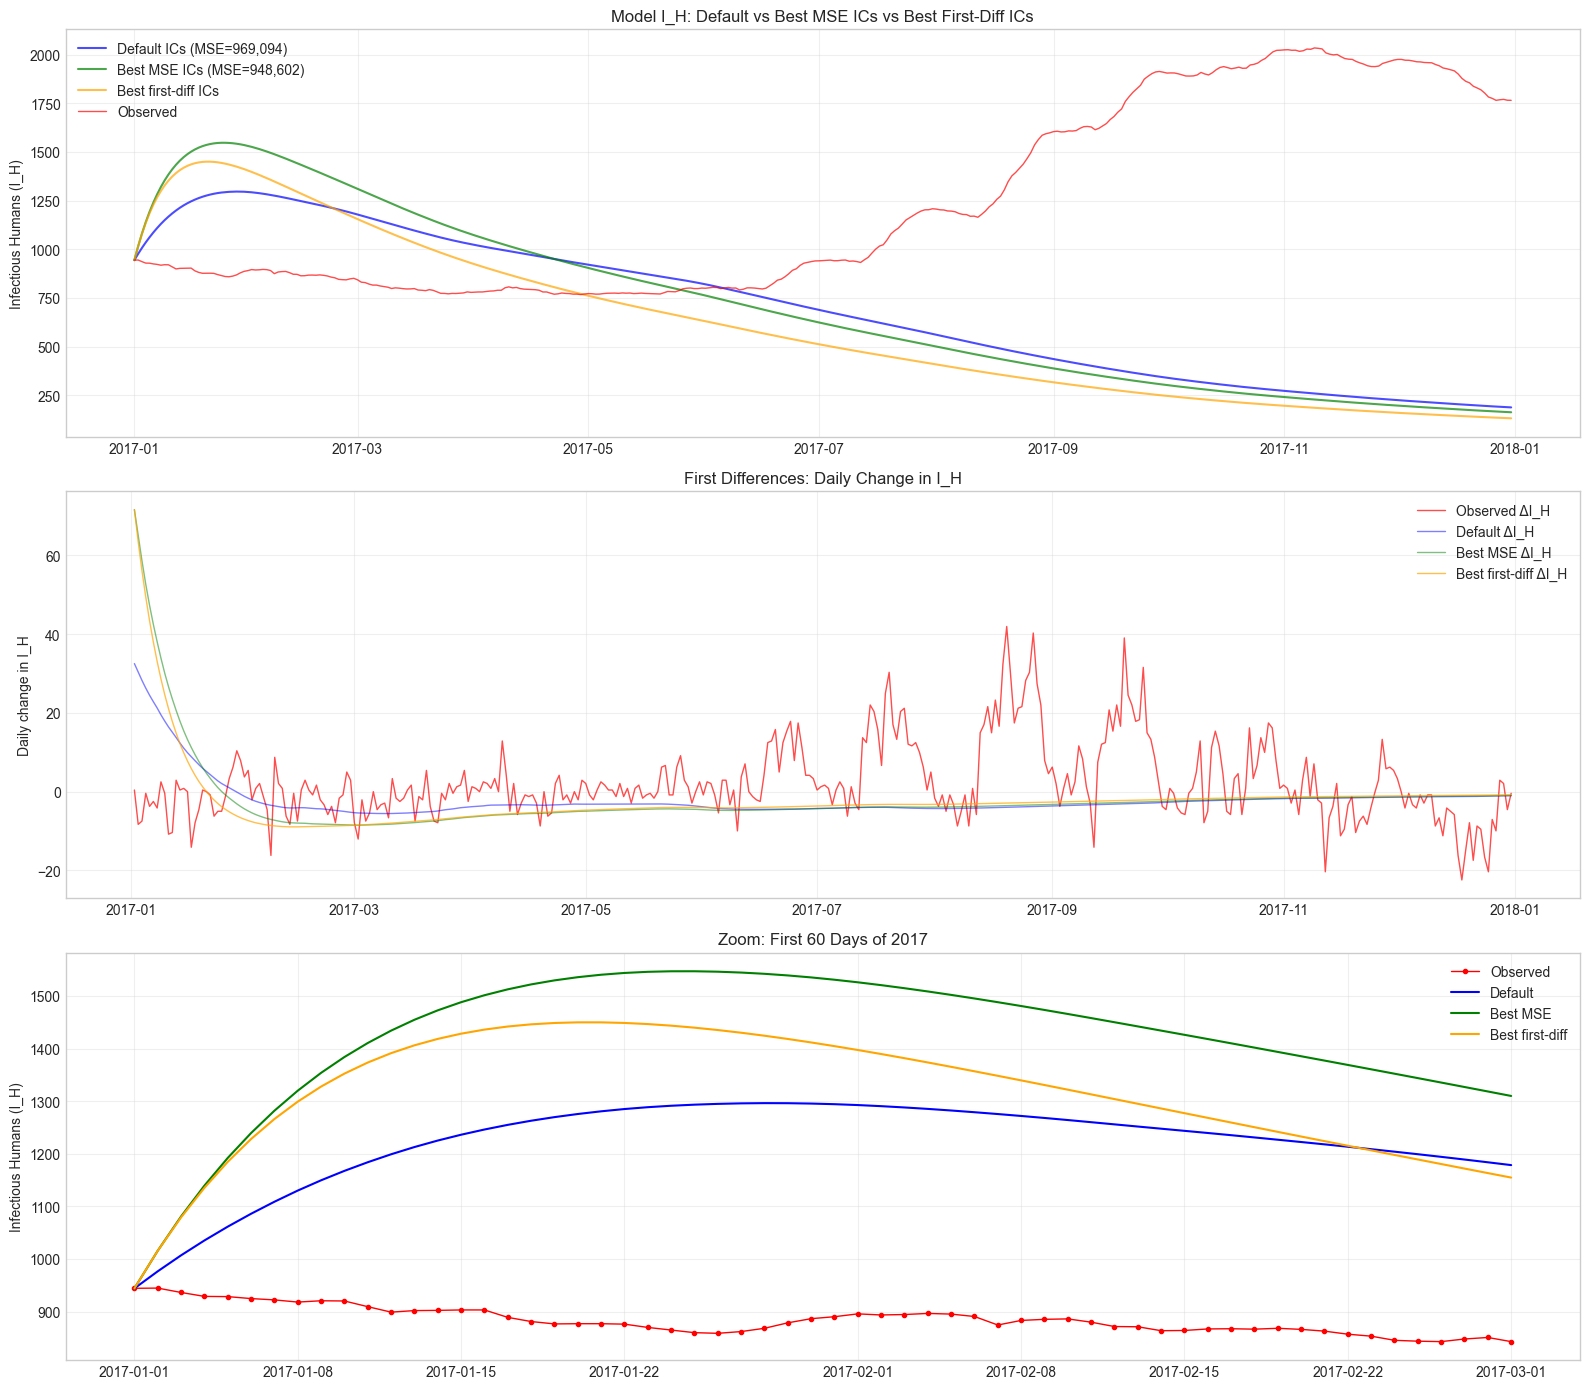

In [20]:
#### Compare: original MSE ICs vs first-difference ICs
opt_init_state_fd = np.array([opt_S_H0_fd, opt_E_H0_fd, I_H0, opt_R_H0_fd, opt_S_M0_fd, opt_E_M0_fd, opt_I_M0_fd])
dates_fd, IH_fd = run_simulation_with_IC(opt_init_state_fd)

# Build the original-optimized state from earlier grid 1 results
orig_sh = 0.75  # replaced by latest grid 1 best
orig_eh = 0.05  # replaced by latest grid 1 best
orig_im = 0.02
orig_S_H0 = round(orig_sh * N_2017)
orig_E_H0 = round(orig_eh * N_2017)
orig_I_M0 = round(orig_im * M_0)
orig_E_M0 = round(3 * orig_I_M0)
orig_R_H0 = N_2017 - orig_S_H0 - orig_E_H0 - I_H0
orig_S_M0 = M_0 - orig_E_M0 - orig_I_M0
opt_init_state = np.array([orig_S_H0, orig_E_H0, I_H0, orig_R_H0, orig_S_M0, orig_E_M0, orig_I_M0])

# Compute MSE for this manually constructed state
d_orig, ih_orig = run_simulation_with_IC(opt_init_state)
interp_orig = interp1d(pd.to_datetime(d_orig).astype(np.int64), ih_orig, kind='linear', fill_value='extrapolate')
obs_int = rural_cases_df['date'].astype(np.int64).values
model_at_obs_orig = interp_orig(obs_int)
observed = rural_cases_df['active_total'].values
orig_abs_mse = np.mean((model_at_obs_orig - observed) ** 2)

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Top: absolute I_H
ax1 = axes[0]
ax1.plot(pd.to_datetime(dates_base), IH_base, 'b-', linewidth=1.5, alpha=0.7,
         label=f'Default ICs (MSE={baseline_mse:,.0f})')
ax1.plot(pd.to_datetime(dates_opt), IH_opt, 'g-', linewidth=1.5, alpha=0.7,
         label=f'Best MSE ICs (MSE={orig_abs_mse:,.0f})')
ax1.plot(pd.to_datetime(dates_fd), IH_fd, 'orange', linewidth=1.5, alpha=0.7,
         label=f'Best first-diff ICs')
ax1.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.0, alpha=0.7, label='Observed')
ax1.set_ylabel('Infectious Humans (I_H)')
ax1.set_title('Model I_H: Default vs Best MSE ICs vs Best First-Diff ICs')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Middle: first differences (daily change)
ax2 = axes[1]
ax2.plot(pd.to_datetime(rural_cases_df['date'].values[1:]),
         np.diff(rural_cases_df['active_total'].values), 'r-', linewidth=1.0, alpha=0.7, label='Observed ΔI_H')
ax2.plot(pd.to_datetime(dates_base)[1:], np.diff(IH_base), 'b-', linewidth=1.0, alpha=0.5, label='Default ΔI_H')
ax2.plot(pd.to_datetime(dates_opt)[1:], np.diff(IH_opt), 'g-', linewidth=1.0, alpha=0.5, label='Best MSE ΔI_H')
ax2.plot(pd.to_datetime(dates_fd)[1:], np.diff(IH_fd), 'orange', linewidth=1.0, alpha=0.7, label='Best first-diff ΔI_H')
ax2.set_ylabel('Daily change in I_H')
ax2.set_title('First Differences: Daily Change in I_H')
ax2.legend(); ax2.grid(True, alpha=0.3)

# Bottom: zoom to first 60 days
ax3 = axes[2]
n_zoom = 60
ax3.plot(rural_cases_df['date'].values[:n_zoom], rural_cases_df['active_total'].values[:n_zoom],
         'ro-', markersize=3, linewidth=1.0, label='Observed')
ax3.plot(pd.to_datetime(dates_base)[:n_zoom], IH_base[:n_zoom], 'b-', linewidth=1.5, label='Default')
ax3.plot(pd.to_datetime(dates_opt)[:n_zoom], IH_opt[:n_zoom], 'g-', linewidth=1.5, label='Best MSE')
ax3.plot(pd.to_datetime(dates_fd)[:n_zoom], IH_fd[:n_zoom], 'orange', linewidth=1.5, label='Best first-diff')
ax3.set_ylabel('Infectious Humans (I_H)')
ax3.set_title(f'Zoom: First {n_zoom} Days of 2017')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
#### Compare results side by side
print("="*65)
print("COMPARISON: Absolute MSE vs First-Difference Fitting")
print("="*65)

# Compute both metrics for each set of ICs
def compute_metrics(init_state, label):
    d, ih = run_simulation_with_IC(init_state)
    interp = interp1d(pd.to_datetime(d).astype(np.int64), ih, kind='linear', fill_value='extrapolate')
    obs_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = interp(obs_int)
    observed = rural_cases_df['active_total'].values
    abs_mse = np.mean((model_at_obs - observed) ** 2)
    model_diff = np.diff(model_at_obs)
    obs_diff = np.diff(observed)
    diff_mse = np.mean((model_diff - obs_diff) ** 2)
    print(f"\n{label}:")
    print(f"  Absolute MSE:     {abs_mse:>12,.2f}")
    print(f"  First-diff MSE:   {diff_mse:>12,.2f}")
    return abs_mse, diff_mse

default_state = initial_state_2017.copy()
compute_metrics(default_state, "Default ICs")
compute_metrics(opt_init_state, "Best MSE ICs")
compute_metrics(opt_init_state_fd, "Best First-Diff ICs")

print(f"\n{'='*65}")
print(f"Best-first-diff ICs: S_H0={opt_S_H0_fd}, E_H0={opt_E_H0_fd}, R_H0={opt_R_H0_fd}, I_M0={opt_I_M0_fd}")
print(f"Best-abs-MSE ICs:    S_H0={opt_S_H0}, E_H0={opt_E_H0}, R_H0={opt_R_H0}, I_M0={opt_I_M0}")


COMPARISON: Absolute MSE vs First-Difference Fitting

Default ICs:
  Absolute MSE:       969,094.00
  First-diff MSE:         155.65

Best MSE ICs:
  Absolute MSE:       948,602.00
  First-diff MSE:         186.21

Best First-Diff ICs:
  Absolute MSE:     1,101,683.22
  First-diff MSE:         200.88

Best-first-diff ICs: S_H0=84, E_H0=837, R_H0=6504, I_M0=84
Best-abs-MSE ICs:    S_H0=1674, E_H0=837, R_H0=4914, I_M0=1674
